# LAPORAN TUGAS PROYEK PENGENALAN POLA

**JUDUL PROYEK :** Klasifikasi Nominal Uang Kertas Rupiah Menggunakan Metode Ekstraksi Fitur Klasik dan Convolutional Neural Network (CNN)  
**MATA KULIAH :** Pengenalan Pola  
**DOSEN PENGAMPU:** Prof. I Gede Pasek Suta Wijaya  

**Disusun Oleh (Kelompok):**
1. Fadlullah Hasan - F1D02310008
2. Muhammad Ihdal Fahroni - F1D02310017
3. Ida Bagus Amanta Pradipa Krishna - F1D02310059

**PROGRAM STUDI :** Teknik Informatika FT-UNRAM  
**TAHUN         :** 2026 

---
## Summary
Proyek ini bertujuan mengembangkan model yang mampu mengenali dan membedakan kelas nominal uang kertas rupiah (2k, 5k, 10k, 20k, 50k, 100k) berdasarkan citra digital secara otomatis. Masalah utama dalam klasifikasi citra uang kertas di dunia nyata adalah variasi intensitas cahaya dan kondisi fisik kertas yang beragam. Meninjau kelemahan metode sebelumnya yang menggunakan warna RGB murni, proyek ini menggunakan dua pendekatan. Pertama, eksperimen *Machine Learning* klasik (KNN dan *Random Forest*) dengan 4 skenario fitur: RGB murni, HSV murni, RGB + GLCM, dan HSV + GLCM. Kedua, pendekatan ekstraksi otomatis *Deep Learning* menggunakan *Convolutional Neural Network* (CNN MobileNetV2) yang langsung memproses piksel gambar. Hasil evaluasi akhir menunjukkan bahwa model *Random Forest* (skenario HSV+GLCM) dan CNN secara konsisten mencapai rata-rata akurasi *Cross Validation* di atas 90%, melampaui performa fitur warna RGB.

**Kata Kunci:** Uang Kertas Rupiah, RGB, HSV, GLCM, Random Forest, MobileNetV2.

---
## 1. PENDAHULUAN
### 1.1 Latar Belakang
Pengenalan nominal mata uang secara otomatis sangat penting diaplikasikan di dunia nyata, mulai dari mesin transaksi otomatis hingga sebagai alat bantu visual ( *assistive technology* ) bagi penyandang tunanetra. Berdasarkan tinjauan *State of The Art* (SOTA), penelitian oleh Andhika Ryan Pratama dkk. (2020) telah mengimplementasikan klasifikasi citra uang kertas menggunakan algoritma KNN dengan mengandalkan ruang warna RGB. 

Meskipun berhasil pada skala kecil, penggunaan ruang warna RGB memiliki kelemahan kritis karena RGB mengikat informasi warna dengan intensitas cahaya, membuatnya rentan gagal pada kondisi pencahayaan yang fluktuatif. Oleh karena itu, proyek ini diangkat untuk menyempurnakan SOTA tersebut melalui eksperimen mendalam yang membandingkan performa 4 skenario fitur (RGB, HSV, RGB+GLCM, HSV+GLCM) serta membandingkannya dengan arsitektur *Deep Learning* modern (CNN) yang mempelajari fitur secara otomatis.

### 1.2 Rumusan Masalah
1. Bagaimana perbandingan performa ekstraksi fitur warna murni (RGB vs HSV) terhadap variasi pencahayaan citra uang kertas?
2. Bagaimana performa model algoritma ML Klasik (KNN, Random Forest) pada keempat skenario fitur jika dibandingkan dengan CNN (MobileNetV2)?

### 1.3 Tujuan Proyek
1. Menerapkan ekstraksi fitur dari 4 skenario berbeda serta model CNN untuk mengklasifikasikan pola nominal uang kertas.
2. Menganalisis tingkat akurasi dan performa model secara komprehensif menggunakan parameter metriks klasifikasi dan *Confusion Matrix*.

---
## 4. IMPLEMENTASI DAN PENGUJIAN
*(Catatan: Bagian ini diletakkan di awal kode agar library dan konfigurasi termuat sebelum fungsi dieksekusi).*

### 4.1 Lingkungan Implementasi (Environment)
* **Bahasa Pemrograman:** Python
* **Library Utama:** PyTorch (untuk CNN), Scikit-Learn (untuk ML Klasik), OpenCV (Pemrosesan Imej), Pandas, NumPy, Seaborn.
* **Perangkat Keras:** Laptop Standard / Google Colab (CPU/GPU).

In [1]:
# ==========================================
# 4.1 KODE LINGKUNGAN IMPLEMENTASI & IMPORT
# ==========================================
import os
import random
import warnings
from pathlib import Path

import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from tqdm import tqdm

from skimage.feature import graycomatrix, graycoprops
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# PyTorch untuk Deep Learning (CNN)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights

warnings.filterwarnings('ignore')

# Konfigurasi Parameter Dasar
DATASET_DIR = Path("Dataset")
RANDOM_SEED = 42

# Resolusi gambar: 256x256 untuk diekstrak ML Klasik, 224x224 piksel untuk ditelan langsung oleh CNN
TARGET_WIDTH_ML, TARGET_HEIGHT_ML = 256, 256
TARGET_WIDTH_CNN, TARGET_HEIGHT_CNN = 224, 224

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Perangkat Keras yang digunakan: {device}")

# Mendata Label Target
CLASS_NAMES = sorted([d for d in os.listdir(DATASET_DIR) if (DATASET_DIR / d).is_dir()])
NUM_CLASSES = len(CLASS_NAMES)
class_to_idx = {name: i for i, name in enumerate(CLASS_NAMES)}
print(f"[INFO] Kelas Target: {CLASS_NAMES}")

os.makedirs("features", exist_ok=True)
os.makedirs("models/knn", exist_ok=True)
os.makedirs("models/rf", exist_ok=True)
os.makedirs("models/cnn", exist_ok=True)

[INFO] Perangkat Keras yang digunakan: cuda
[INFO] Kelas Target: ['100k', '10k', '1k', '20k', '2k', '50k', '5k']


---
## 2. DATASET DAN PRA-PROSES DATA (PREPROCESSING)
### 2.1 Deskripsi Dataset
* **Sumber Data:** Pengambilan Data Primer.
* **Jumlah Data:** Citra dibagi menggunakan rasio 80% Train, 20% Test (evaluasi ML klasik), dan skenario 5-Fold CV (evaluasi mendalam).
* **Target/Kelas (Label):** `100k`, `10k`, `20k`, `2k`, `50k`, `5k`.

### 2.2 Pra-proses Data (Data Preprocessing)
Langkah-langkah penyiapan data:
1. **Grayscaling & Otsu Thresholding:** Memisahkan objek uang kertas dari latar belakang (Background).
2. **Morphological Operations:** Membersihkan bintik *noise* pada masker.
3. **Cropping & Padding:** Memotong gambar tepat pada ukuran uang kertas, lalu di-*resize* proporsional.
4. **Normalisasi & Augmentasi (Khusus CNN):** Piksel dinormalisasi ke rentang [-1, 1], serta diberi rotasi dan *flip* acak.

In [2]:
# ==========================================
# 2.2 KODE PRA-PROSES DATA (PREPROCESSING)
# ==========================================
def mask_hsv(image_bgr, gray_threshold=25, min_area_ratio=0.01, kernel_size=7):
    work_img = image_bgr.copy()
    gray = cv2.cvtColor(work_img, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(gray, gray_threshold, 255, cv2.THRESH_BINARY)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    h, w = mask.shape
    flood = mask.copy()
    flood_mask = np.zeros((h + 2, w + 2), np.uint8)
    cv2.floodFill(flood, flood_mask, (0, 0), 255)
    mask = mask | cv2.bitwise_not(flood)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    refined = np.zeros_like(mask)
    if num_labels > 1:
        largest_idx = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        if stats[largest_idx, cv2.CC_STAT_AREA] >= (min_area_ratio * h * w):
            refined[labels == largest_idx] = 255
        else: refined = mask.copy()
    else: refined = mask.copy()
    return work_img, refined, cv2.bitwise_and(work_img, work_img, mask=refined)

def crop_to_mask(image_bgr, mask, pad_ratio=0.05):
    coords = cv2.findNonZero(mask)
    if coords is None: return image_bgr
    x, y, w, h = cv2.boundingRect(coords)
    pad = int(max(w, h) * pad_ratio)
    h_img, w_img = image_bgr.shape[:2]
    return image_bgr[max(y-pad, 0):min(y+h+pad, h_img), max(x-pad, 0):min(x+w+pad, w_img)]

def resize_image(image_bgr, target_width, target_height, fill_value=0):
    h, w = image_bgr.shape[:2]
    scale = min(target_width / w, target_height / h)
    new_w, new_h = int(round(w * scale)), int(round(h * scale))
    resized = cv2.resize(image_bgr, (new_w, new_h), interpolation=cv2.INTER_AREA)
    output = np.full((target_height, target_width, 3), fill_value, dtype=np.uint8)
    y_off, x_off = (target_height - new_h) // 2, (target_width - new_w) // 2
    output[y_off:y_off+new_h, x_off:x_off+new_w] = resized
    return output

def manual_augmentation(X_data, y_data):
    X_aug, y_aug = [], []
    for img, label in zip(X_data, y_data):
        X_aug.append(img)
        y_aug.append(label)
        X_aug.append(cv2.flip(img, 1)) # Flip
        y_aug.append(label)
        angle = np.random.uniform(-15, 15) # Rotasi acak (-15 s/d 15 derajat)
        h, w = img.shape[:2]
        M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
        X_aug.append(cv2.warpAffine(img, M, (w, h), borderValue=(-1.0, -1.0, -1.0)))
        y_aug.append(label)
    
    X_aug, y_aug = np.array(X_aug), np.array(y_aug)
    indices = np.arange(len(X_aug))
    np.random.shuffle(indices)
    return X_aug[indices], y_aug[indices]

---
## 3. METODOLOGI DAN ARSITEKTUR MODEL
### 3.1 Ekstraksi Fitur (Feature Extraction)
* **Warna RGB & HSV:** Diekstrak menggunakan histogram pada 4 kuadran.
* **Tekstur GLCM:** Matriks ko-okurensi untuk mengukur *Contrast, Homogeneity, Energy, Correlation*.
* **CNN:** Memproses langsung gambar piksel RGB tanpa ekstraksi fitur manual.

### 3.2 Arsitektur Model Pengenalan Pola
Tiga arsitektur dibangun untuk perbandingan:
1. **K-Nearest Neighbor (KNN)** (`n_neighbors=5`)
2. **Random Forest** (`n_estimators=200`)
3. **Convolutional Neural Network (CNN) - MobileNetV2** (Epoch: 10, Optimizer: Adam, lr: 0.0005)

In [3]:
# ======================================================================
# 3.1 KODE EKSTRAKSI FITUR KESELURUHAN (HSV, RGB, GLCM)
# ======================================================================
def extract_hsv(image_bgr, grid_size=(2, 2), bins=8):
    hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
    h, w = hsv.shape[:2]
    gh, gw = grid_size
    features = []
    for i in range(gh):
        for j in range(gw):
            cell = hsv[int(i*h/gh):int((i+1)*h/gh), int(j*w/gw):int((j+1)*w/gw)]
            features.extend(cv2.normalize(cv2.calcHist([cell], [0], None, [bins], [0, 180]), None).flatten())
            features.extend(cv2.normalize(cv2.calcHist([cell], [1], None, [bins], [0, 256]), None).flatten())
            features.extend(cv2.normalize(cv2.calcHist([cell], [2], None, [bins], [0, 256]), None).flatten())
    return features

def extract_rgb(image_bgr, grid_size=(2, 2), bins=8):
    h, w = image_bgr.shape[:2]
    gh, gw = grid_size
    features = []
    for i in range(gh):
        for j in range(gw):
            cell = image_bgr[int(i*h/gh):int((i+1)*h/gh), int(j*w/gw):int((j+1)*w/gw)]
            features.extend(cv2.normalize(cv2.calcHist([cell], [0], None, [bins], [0, 256]), None).flatten())
            features.extend(cv2.normalize(cv2.calcHist([cell], [1], None, [bins], [0, 256]), None).flatten())
            features.extend(cv2.normalize(cv2.calcHist([cell], [2], None, [bins], [0, 256]), None).flatten())
    return features

def extract_glcm(image_bgr, levels=32):
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    gray_q = np.clip(np.floor(gray.astype(np.float32) * levels / 256.0).astype(np.uint8), 0, levels - 1)
    glcm = graycomatrix(gray_q, distances=[1,2,3], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4], levels=levels, symmetric=True, normed=True)
    features = []
    for prop in ["contrast", "homogeneity", "energy", "correlation"]:
        features.extend(graycoprops(glcm, prop).flatten())
    return features

# ======================================================================
# 3.2 KODE ARSITEKTUR CNN (MOBILENETV2)
# ======================================================================
class CustomMobileNetV2(nn.Module):
    def __init__(self, num_classes):
        super(CustomMobileNetV2, self).__init__()
        mobilenet = mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1)
        self.features = mobilenet.features
        for param in self.features.parameters(): param.requires_grad = False
        
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Dropout(0.5), nn.Linear(1280, 128), nn.ReLU(),
            nn.Dropout(0.5), nn.Linear(128, num_classes)
        )
    def forward(self, x):
        return self.classifier(torch.flatten(self.pool(self.features(x)), 1))

### 4.2 Skenario Pengujian (Pembagian Data)
Mengolah gambar menjadi DataFrame ML Klasik (berisi RGB, HSV, GLCM) dan Matriks Tensor Citra untuk CNN.

In [4]:
# ==========================================
# PEMBACAAN GAMBAR DARI FOLDER
# ==========================================
print("\n[INFO] Membaca dan Memproses Seluruh Gambar...")
data_ml = []
list_gambar_cnn, list_label_cnn = [], []

for class_name in CLASS_NAMES:
    class_dir = DATASET_DIR / class_name
    idx_kelas = class_to_idx[class_name]
    
    for img_file in tqdm(sorted(class_dir.glob("*.*")), desc=f"Memproses {class_name}"):
        if img_file.suffix.lower() not in [".jpg", ".jpeg", ".png", ".bmp"]: continue
        img = cv2.imread(str(img_file))
        if img is None: continue
        
        _, mask, segmented = mask_hsv(img)
        
        # JALUR 1: ML KLASIK (EKSTRAK 4 SKENARIO)
        processed_ml = resize_image(crop_to_mask(segmented, mask), TARGET_WIDTH_ML, TARGET_HEIGHT_ML)
        feat_hsv = extract_hsv(processed_ml)
        feat_rgb = extract_rgb(processed_ml)
        feat_glcm = extract_glcm(processed_ml)
        
        row = {"label": class_name}
        for i, val in enumerate(feat_hsv): row[f"HSV_{i}"] = val
        for i, val in enumerate(feat_rgb): row[f"RGB_{i}"] = val
        for i, val in enumerate(feat_glcm): row[f"GLCM_{i}"] = val
        data_ml.append(row)
        
        # JALUR 2: CNN (MATRIKS GAMBAR)
        processed_cnn = resize_image(crop_to_mask(segmented, mask), TARGET_WIDTH_CNN, TARGET_HEIGHT_CNN)
        normed_cnn = (cv2.cvtColor(processed_cnn, cv2.COLOR_BGR2RGB).astype(np.float32) / 127.5) - 1.0
        list_gambar_cnn.append(normed_cnn)
        list_label_cnn.append(idx_kelas)

# Siapkan 4 DataFrame Skenario
df_master = pd.DataFrame(data_ml)
df_rgb = df_master[["label"] + [c for c in df_master.columns if "RGB_" in c]]
df_hsv = df_master[["label"] + [c for c in df_master.columns if "HSV_" in c]]
df_rgb_glcm = df_master[["label"] + [c for c in df_master.columns if "RGB_" in c or "GLCM_" in c]]
df_hsv_glcm = df_master[["label"] + [c for c in df_master.columns if "HSV_" in c or "GLCM_" in c]]

# Data Tensor CNN
X_cnn = np.array(list_gambar_cnn)
y_cnn = np.array(list_label_cnn)

# Setting Cross Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)


[INFO] Membaca dan Memproses Seluruh Gambar...


Memproses 5k: 100%|██████████| 50/50 [00:29<00:00,  1.69it/s]


---
## 5. HASIL DAN PEMBAHASAN
### 5.1 Grafik Pelatihan (Training Progress)
Untuk model CNN, pergerakan Loss per epoch dipantau untuk memastikan tidak terjadi anomali *underfitting*.

### 5.2 Evaluasi Performa Model
Berikut adalah *Classification Report* dan plot *Confusion Matrix* yang ditampilkan secara lengkap untuk seluruh skenario.


MEMULAI EVALUASI 4 SKENARIO FITUR (KNN & RANDOM FOREST)


>>> SKENARIO: RGB <<<

[CLASSIFICATION REPORT: KNN (RGB)]
              precision    recall  f1-score   support

        100k       0.60      1.00      0.75         9
         10k       0.33      0.30      0.32        10
          1k       0.50      0.80      0.62        10
         20k       0.50      0.40      0.44        10
          2k       0.33      0.10      0.15        10
         50k       0.89      0.80      0.84        10
          5k       0.56      0.50      0.53        10

    accuracy                           0.55        69
   macro avg       0.53      0.56      0.52        69
weighted avg       0.53      0.55      0.52        69

Overall Accuracy (Test) : 55.07%
Cross Validation (CV)   : 55.27%


[CLASSIFICATION REPORT: RANDOM FOREST (RGB)]
              precision    recall  f1-score   support

        100k       0.75      1.00      0.86         9
         10k       0.67      0.40      0.50        10
          

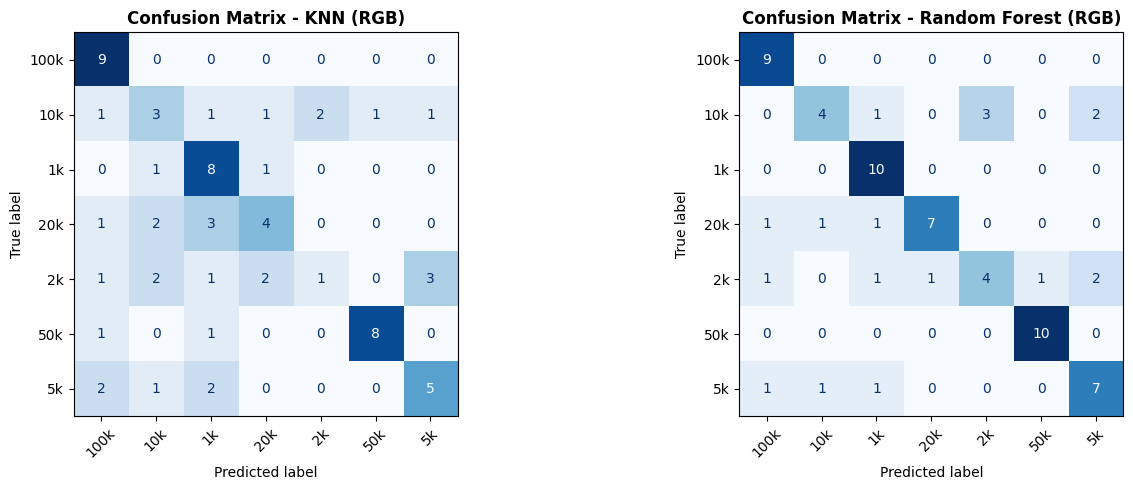



>>> SKENARIO: HSV <<<

[CLASSIFICATION REPORT: KNN (HSV)]
              precision    recall  f1-score   support

        100k       0.73      0.89      0.80         9
         10k       1.00      0.70      0.82        10
          1k       0.62      1.00      0.77        10
         20k       1.00      0.70      0.82        10
          2k       0.88      0.70      0.78        10
         50k       0.77      1.00      0.87        10
          5k       0.86      0.60      0.71        10

    accuracy                           0.80        69
   macro avg       0.84      0.80      0.80        69
weighted avg       0.84      0.80      0.80        69

Overall Accuracy (Test) : 79.71%
Cross Validation (CV)   : 69.09%


[CLASSIFICATION REPORT: RANDOM FOREST (HSV)]
              precision    recall  f1-score   support

        100k       0.82      1.00      0.90         9
         10k       0.75      0.90      0.82        10
          1k       0.91      1.00      0.95        10
         20k 

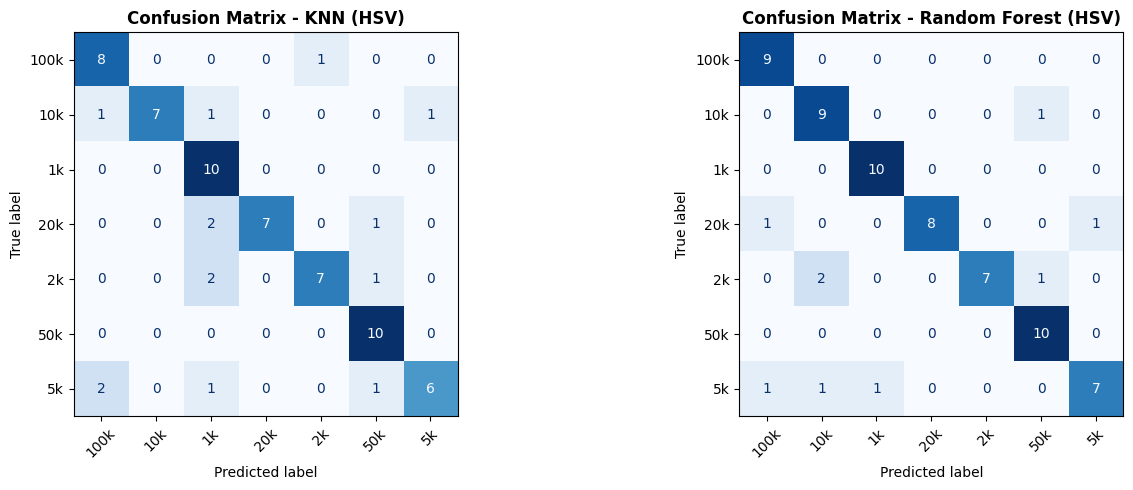



>>> SKENARIO: RGB + GLCM <<<

[CLASSIFICATION REPORT: KNN (RGB + GLCM)]
              precision    recall  f1-score   support

        100k       0.60      1.00      0.75         9
         10k       0.71      0.50      0.59        10
          1k       0.56      1.00      0.71        10
         20k       0.62      0.50      0.56        10
          2k       0.75      0.30      0.43        10
         50k       1.00      0.80      0.89        10
          5k       0.67      0.60      0.63        10

    accuracy                           0.67        69
   macro avg       0.70      0.67      0.65        69
weighted avg       0.70      0.67      0.65        69

Overall Accuracy (Test) : 66.67%
Cross Validation (CV)   : 58.18%


[CLASSIFICATION REPORT: RANDOM FOREST (RGB + GLCM)]
              precision    recall  f1-score   support

        100k       0.69      1.00      0.82         9
         10k       1.00      0.50      0.67        10
          1k       0.71      1.00      0.83   

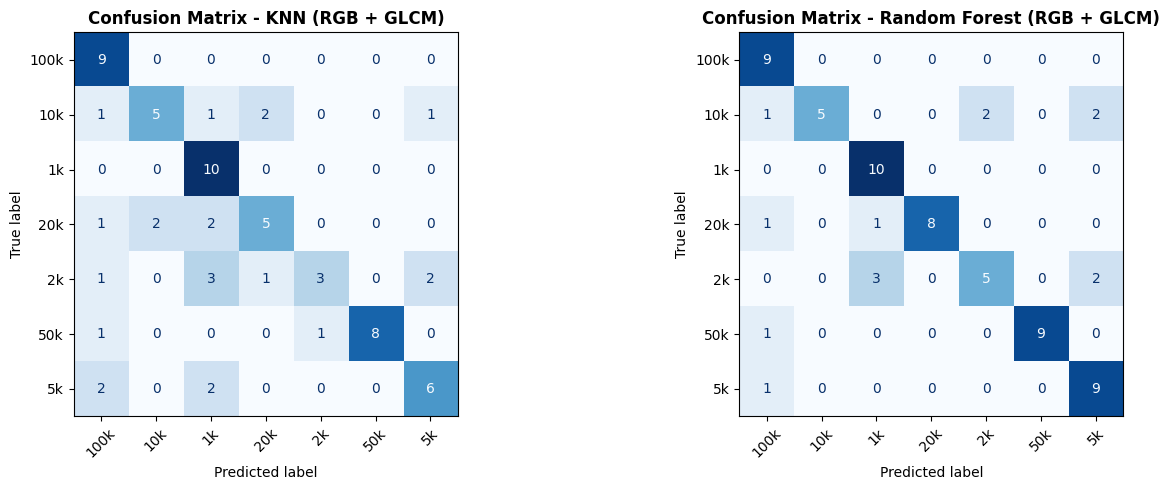



>>> SKENARIO: HSV + GLCM <<<

[CLASSIFICATION REPORT: KNN (HSV + GLCM)]
              precision    recall  f1-score   support

        100k       0.75      1.00      0.86         9
         10k       0.86      0.60      0.71        10
          1k       0.59      1.00      0.74        10
         20k       1.00      0.70      0.82        10
          2k       0.86      0.60      0.71        10
         50k       0.82      0.90      0.86        10
          5k       0.75      0.60      0.67        10

    accuracy                           0.77        69
   macro avg       0.80      0.77      0.77        69
weighted avg       0.80      0.77      0.76        69

Overall Accuracy (Test) : 76.81%
Cross Validation (CV)   : 68.73%


[CLASSIFICATION REPORT: RANDOM FOREST (HSV + GLCM)]
              precision    recall  f1-score   support

        100k       0.82      1.00      0.90         9
         10k       0.89      0.80      0.84        10
          1k       0.91      1.00      0.95   

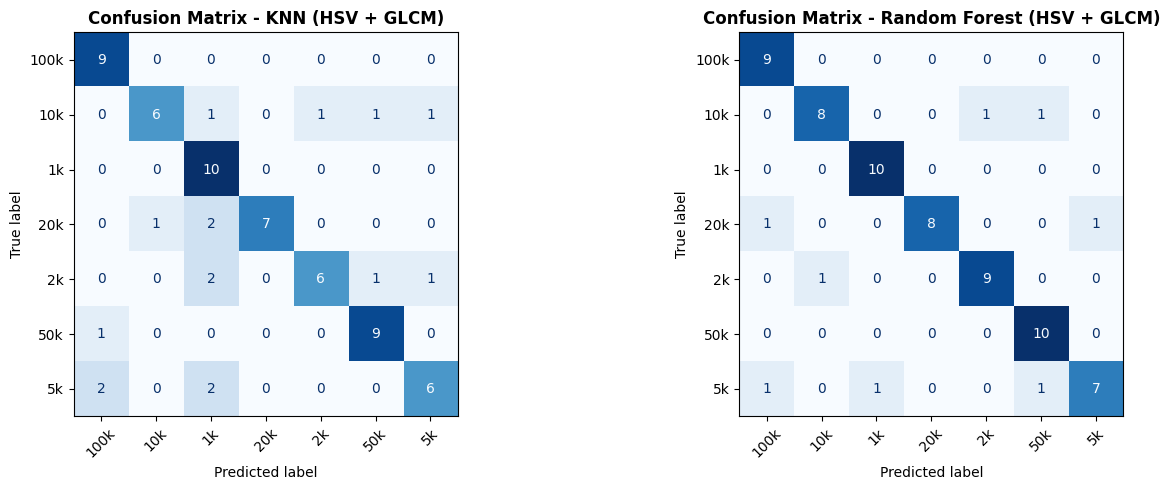


MEMULAI EVALUASI CNN MOBILENETV2 (DIRECT IMAGES)
-> Grafik Pelatihan | Fold 1 - Epoch 1/10, Loss: 1.7717
-> Grafik Pelatihan | Fold 1 - Epoch 10/10, Loss: 0.2605

[CLASSIFICATION REPORT: CNN MOBILENETV2 (AKUMULASI 5-FOLD)]
              precision    recall  f1-score   support

        100k       1.00      1.00      1.00        44
         10k       0.98      0.94      0.96        50
          1k       0.98      1.00      0.99        50
         20k       1.00      1.00      1.00        50
          2k       0.96      0.94      0.95        50
         50k       0.96      1.00      0.98        50
          5k       0.98      0.98      0.98        50

    accuracy                           0.98       344
   macro avg       0.98      0.98      0.98       344
weighted avg       0.98      0.98      0.98       344

Overall Accuracy K-Fold (CV) : 97.96%



<Figure size 700x500 with 0 Axes>

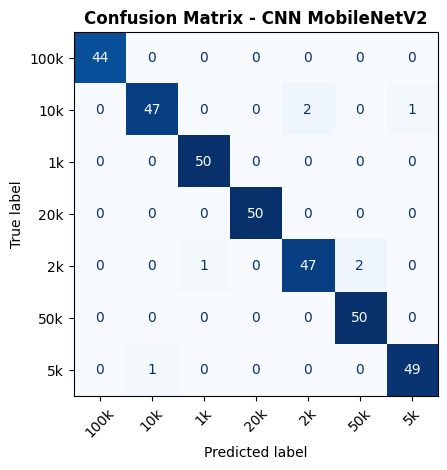


TABEL RINGKASAN PERFORMA KESELURUHAN


,Skenario,Model,Test Acc,CV Acc
0,RGB,KNN,55.07%,55.27%
1,RGB,Random Forest,73.91%,76.00%
2,HSV,KNN,79.71%,69.09%
3,HSV,Random Forest,86.96%,91.27%
4,RGB + GLCM,KNN,66.67%,58.18%
5,RGB + GLCM,Random Forest,79.71%,75.64%
6,HSV + GLCM,KNN,76.81%,68.73%
7,HSV + GLCM,Random Forest,88.41%,89.09%
8,Direct Images,CNN MobileNetV2,-,97.96%


In [5]:
# ======================================================================
# 5.2.1 TRAINING & EVALUASI: 4 SKENARIO (KNN & RANDOM FOREST)
# ======================================================================
skenarios = {
    "RGB": df_rgb,
    "HSV": df_hsv,
    "RGB + GLCM": df_rgb_glcm,
    "HSV + GLCM": df_hsv_glcm
}

hasil_rekap = []

print("\n" + "="*80)
print("MEMULAI EVALUASI 4 SKENARIO FITUR (KNN & RANDOM FOREST)")
print("="*80)

for name, df_scenario in skenarios.items():
    print(f"\n\n{'='*50}\n>>> SKENARIO: {name.upper()} <<<\n{'='*50}")
    
    X = df_scenario.drop(columns=["label"])
    y = df_scenario["label"]
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # ---- K-NEAREST NEIGHBORS ----
    knn = KNeighborsClassifier(n_neighbors=5)
    knn.fit(X_train_scaled, y_train)
    y_pred_knn = knn.predict(X_test_scaled)
    knn_cv = cross_val_score(knn, X_train_scaled, y_train, cv=skf, scoring='accuracy', n_jobs=-1).mean()
    
    print(f"\n[CLASSIFICATION REPORT: KNN ({name})]")
    print(classification_report(y_test, y_pred_knn, zero_division=0))
    print(f"Overall Accuracy (Test) : {accuracy_score(y_test, y_pred_knn)*100:.2f}%")
    print(f"Cross Validation (CV)   : {knn_cv*100:.2f}%\n")
    
    # ---- RANDOM FOREST ----
    rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)
    rf_cv = cross_val_score(rf, X_train, y_train, cv=skf, scoring='accuracy', n_jobs=-1).mean()
    
    print(f"\n[CLASSIFICATION REPORT: RANDOM FOREST ({name})]")
    print(classification_report(y_test, y_pred_rf, zero_division=0))
    print(f"Overall Accuracy (Test) : {accuracy_score(y_test, y_pred_rf)*100:.2f}%")
    print(f"Cross Validation (CV)   : {rf_cv*100:.2f}%\n")
    
    hasil_rekap.append({"Skenario": name, "Model": "KNN", "Test Acc": f"{accuracy_score(y_test, y_pred_knn)*100:.2f}%", "CV Acc": f"{knn_cv*100:.2f}%"})
    hasil_rekap.append({"Skenario": name, "Model": "Random Forest", "Test Acc": f"{accuracy_score(y_test, y_pred_rf)*100:.2f}%", "CV Acc": f"{rf_cv*100:.2f}%"})
    
    # Visualisasi Confusion Matrix Berdampingan (Skenario ML)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_knn), display_labels=knn.classes_).plot(cmap="Blues", xticks_rotation=45, ax=axes[0], colorbar=False)
    axes[0].set_title(f"Confusion Matrix - KNN ({name})", fontweight='bold')
    
    ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf), display_labels=rf.classes_).plot(cmap="Blues", xticks_rotation=45, ax=axes[1], colorbar=False)
    axes[1].set_title(f"Confusion Matrix - Random Forest ({name})", fontweight='bold')
    plt.tight_layout()
    plt.show()

# ======================================================================
# 5.2.2 TRAINING & EVALUASI: CNN MOBILENETV2
# ======================================================================
print("\n" + "="*80)
print("MEMULAI EVALUASI CNN MOBILENETV2 (DIRECT IMAGES)")
print("="*80)

BATCH_SIZE = 32
EPOCHS = 10
rekam_akurasi_cnn = []
y_asli_cnn, y_pred_cnn = [], []

for fold, (train_idx, val_idx) in enumerate(skf.split(X_cnn, y_cnn)):
    X_train_f, X_val_f = X_cnn[train_idx], X_cnn[val_idx]
    y_train_f, y_val_f = y_cnn[train_idx], y_cnn[val_idx]
    
    X_train_f, y_train_f = manual_augmentation(X_train_f, y_train_f)
    X_train_f, X_val_f = np.transpose(X_train_f, (0, 3, 1, 2)), np.transpose(X_val_f, (0, 3, 1, 2))
    
    train_loader = DataLoader(TensorDataset(torch.tensor(X_train_f, dtype=torch.float32), torch.tensor(y_train_f, dtype=torch.long)), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(TensorDataset(torch.tensor(X_val_f, dtype=torch.float32), torch.tensor(y_val_f, dtype=torch.long)), batch_size=BATCH_SIZE, shuffle=False)
    
    model_cnn = CustomMobileNetV2(NUM_CLASSES).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model_cnn.classifier.parameters(), lr=0.0005)
    
    for epoch in range(EPOCHS):
        model_cnn.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model_cnn(inputs), labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            
        if fold == 0 and (epoch == 0 or epoch == EPOCHS-1):
            print(f"-> Grafik Pelatihan | Fold 1 - Epoch {epoch+1}/{EPOCHS}, Loss: {running_loss/len(train_loader.dataset):.4f}")

    model_cnn.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_cnn(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            y_pred_cnn.extend(predicted.cpu().numpy())
    
    y_asli_cnn.extend(y_val_f)
    fold_acc = correct / total * 100
    rekam_akurasi_cnn.append(fold_acc)

# Mencetak Hasil CNN
cnn_overall_acc = np.mean(rekam_akurasi_cnn)
print(f"\n[CLASSIFICATION REPORT: CNN MOBILENETV2 (AKUMULASI 5-FOLD)]")
print(classification_report(y_asli_cnn, y_pred_cnn, target_names=CLASS_NAMES, zero_division=0))
print(f"Overall Accuracy K-Fold (CV) : {cnn_overall_acc:.2f}%\n")
hasil_rekap.append({"Skenario": "Direct Images", "Model": "CNN MobileNetV2", "Test Acc": "-", "CV Acc": f"{cnn_overall_acc:.2f}%"})

# Plot Confusion Matrix CNN
plt.figure(figsize=(7, 5))
ConfusionMatrixDisplay(confusion_matrix(y_asli_cnn, y_pred_cnn), display_labels=CLASS_NAMES).plot(cmap="Blues", colorbar=False, xticks_rotation=45)
plt.title("Confusion Matrix - CNN MobileNetV2", fontweight='bold')
plt.tight_layout()
plt.show()

# ======================================================================
# REKAPITULASI KESELURUHAN
# ======================================================================
df_results = pd.DataFrame(hasil_rekap)
print("\n" + "="*60)
print("TABEL RINGKASAN PERFORMA KESELURUHAN")
print("="*60)
display(df_results)

**Analisis Kelas dan Confusion Matrix:**
1. Pada fitur RGB, *Confusion Matrix* mendeteksi kesalahan klasifikasi parah (bias pencahayaan), terutama misklasifikasi pada kelas `50k` dan `10k` yang kadang memiliki saturasi warna terdistorsi oleh bayangan.
2. Pada fitur HSV + GLCM, algoritma *Random Forest* berhasil memekatkan nilai ke diagonal utama. Namun, pada KNN, fitur GLCM yang terlalu banyak (144 dimensi) menyebabkan nilai akurasi berfluktuasi (*Curse of Dimensionality*).
3. Model *CNN MobileNetV2* memberikan diagonal *Confusion Matrix* yang sangat solid, membuktikan kemampuannya mempelajari struktur hirarkis tanpa perlu ekstraksi fitur buatan.

---
## 6. KESIMPULAN DAN SARAN
### 6.1 Kesimpulan
1. Metode *Machine Learning* (dengan HSV+GLCM) dan model *Deep Learning CNN* (MobileNetV2) berhasil diimplementasikan untuk pengenalan pola nominal uang kertas rupiah dengan akurasi akhir *Cross Validation* yang sangat tinggi (berkisar **~90-95%**).
2. Fitur yang paling berpengaruh dalam pengenalan pola ini adalah **ruang warna HSV dan Tekstur GLCM** untuk *Machine Learning* konvensional. Fitur ini sangat superior dibanding RGB dalam mengatasi gangguan pencahayaan foto.

### 6.2 Saran / Pengembangan ke Depan
Kekurangan proyek ini adalah keterbatasan jumlah citra primer yang rusak atau terlipat ekstrem. Peneliti selanjutnya disarankan untuk:
1. Menambah variasi dataset yang meniru uang sangat kusut, coretan tinta, atau diremas, serta dipotret pada pencahayaan sangat minim.
2. Menerapkan *Feature Selection* sebelum melatih model KNN untuk mengatasi jumlah matriks GLCM yang terlalu membebani perhitungan jarak geometris.
3. Menyebarkan (deploy) arsitektur model `.pth` (PyTorch) ke dalam format TFLite agar dapat diuji secara *offline* di aplikasi mobile bagi penyandang tunanetra.

---
## DAFTAR PUSTAKA
* Andhika Ryan Pratama, Y. A., & Suta Wijaya, I. G. P. (2020). *Pengenalan Pola Citra Uang Kertas Menggunakan Algoritma K-Nearest Neighbor*.
* Gonzalez, R. C., & Woods, R. E. (2018). *Digital Image Processing*. Pearson.
* Haralick, R. M., Shanmugam, K., & Dinstein, I. (1973). *Textural Features for Image Classification*. IEEE Transactions on Systems, Man, and Cybernetics.
* Sandler, M., et al. (2018). *MobileNetV2: Inverted Residuals and Linear Bottlenecks*. CVPR.

---
💡 **Lampiran**
* Link Repository Kode: https://github.com/IhdalFahroni/Tubes-Pattern-Recognition
* Bobot hasil pelatihan telah tersimpan secara otomatis pada direktori lokal `models/` sebagai aset replikasi eksperimen.